In [1]:
import numpy as np 
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import myfun as wf
import math, gc, logging,os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import geocat.viz as gv

In [2]:
fname = "/glade/derecho/scratch/hcluo/v_MSE_corr800.nc"
ds1 = xr.open_dataset(fname)["v_MSE_corr"]
BOUNDARY  = [-20,20,0,360]    

In [3]:
print(ds1.values)

[[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan 

DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/glade/u/home/hcluo/miniconda3/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansDisplay.ttf', name='DejaVu Sans Display', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/glade/u/home/hcluo/miniconda3/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymReg.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/glade/u/home/hcluo/minico

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x7fd1663ad1e0>
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=13.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/glade/u/home/hcluo/miniconda3/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansDisplay.ttf', name='DejaVu Sans Display', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/glade/u/home/hcluo/miniconda3/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymReg.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/glade/u/home/hcluo/miniconda3/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif.ttf', name='DejaVu Serif', 

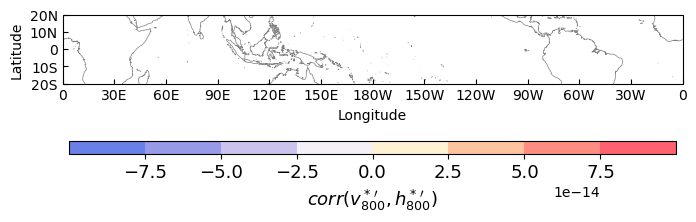

In [ ]:
lb_ticks = np.linspace(-0.3,0.3,11)
x_ticks = np.arange(-180,180+30,30)
y_ticks = np.arange(BOUNDARY[0],BOUNDARY[1]+10,10)
x_labels = [f"{abs(lon)}W" if lon < 0 else (f"{lon}" if lon == 0 else f"{lon}E") for lon in ((x_ticks+360)% 360 - 180)]
y_labels = [f"{abs(lat)}S" if lat < 0 else (f"{lat}" if lat == 0 else f"{lat}N") for lat in y_ticks]
    
fig, ax = plt.subplots(
        nrows=1, ncols=1,
        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
        figsize=(8, 5)
    )

shadings = ax.contourf(ds1.longitude-180, ds1.latitude, ds1,
                       levels=lb_ticks,
                       extend='both',
                       cmap = wf.colormap(color="PurOra"))
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Longitude")
ax.set_ylim([y_ticks[0],y_ticks[-1]])
ax.coastlines(linewidth=0.5, zorder=1,color='gray')
ax.tick_params(direction='in', which='both')
    
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
ax.set_ylabel("Latitude")
cbar = plt.colorbar(shadings,ax=ax,
                                 extendrect = True,
                                 extendfrac = 'auto',
                                 orientation='horizontal',
                                 ticks=lb_ticks,
                                 shrink=0.98,
                                 aspect = 50,
                                 drawedges=False)#,
                                 #pad=0.04)
cbar.ax.tick_params(labelsize=13)
cbar.ax.xaxis.set_label_position('bottom')
cbar.set_label(label=r"$corr(v_{800}^*', h_{800}^*')$", size=13,loc = 'center')
plt.savefig("climatology_corr800.pdf",bbox_inches='tight')